# Differentiable MEMS Pull-In — 90-second demo

**ISMC 2026, Track 2 (AI for MEMS).** Runs end to end on a laptop CPU in about
90 seconds. No COMSOL, no ANSYS, no MATLAB, no training data, no GPU.

What this notebook shows, in order:

1. A baseline electrostatic cantilever sized to a 2 µm travel specification —
   it needs **22.86 V**.
2. That pull-in is a **saddle-node bifurcation**, and that we solve for it
   *directly* rather than creeping up on it.
3. That the gradient of pull-in voltage with respect to electrode geometry is
   **exact** — verified against an analytic scaling law to 0.000000%.
4. Gradient descent on the gap profile driving **22.86 V → 14.04 V** live,
   while holding the travel specification at exactly 2.0000 µm.

Run it top to bottom.


## Setup

CPU is forced on purpose. The static solver needs float64 — fp32 does not converge (residual 2.0 versus 1e-8) — and consumer GPUs run fp64 at roughly 1/64 rate, so CPU is both faster here and reproducible on any machine.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import time
import jax, jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jax import jit

import beam as B
from inverse_design import (ALPHA, TRAVEL_REQ, N_FINAL, K,
                            volts, evaluate, size_for_travel, shape_norm)

BC = B.CANTILEVER
N  = N_FINAL                      # matched grid for every headline number
xi = B.node_xi(N, BC)
M  = B._unknown_count(N, BC)

print("JAX", jax.__version__, "| device:", jax.devices()[0])
print("x64 enabled:", jax.config.jax_enable_x64)
print(f"specification: {TRAVEL_REQ} um of stable travel, cantilever, N={N}")

JAX 0.10.2 | device: cpu:0
x64 enabled: True
specification: 2.0 um of stable travel, cantilever, N=60


## 1. The baseline device

A silicon cantilever over a **uniform** electrode gap. We bisect the gap so the
device delivers exactly the required 2 µm of stable travel, then ask what drive
voltage that costs.

This is the design a competent engineer produces without optimisation, and it
is the number the 41% is measured against.

In [2]:
t0 = time.perf_counter()

d_uni = float(size_for_travel(lambda c: jnp.full(M, c), 1.05, 25.0, N, BC))
D_uni = jnp.full(M, d_uni)
lam_u, tr_u, res_u, _ = evaluate(D_uni, N, BC)
V_uni = float(volts(lam_u))

print(f"uniform gap        d = {d_uni:.3f} um")
print(f"stable travel        = {float(tr_u):.4f} um   (spec {TRAVEL_REQ})")
print(f"pull-in voltage      = {V_uni:.3f} V")
print(f"solver residual      = {float(res_u):.1e}")
print(f"[{time.perf_counter() - t0:.1f}s]")

uniform gap        d = 4.463 um
stable travel        = 2.0000 um   (spec 2.0)
pull-in voltage      = 22.864 V
solver residual      = 5.8e-08
[7.2s]


## 2. Pull-in is a fold, not a maximum

Sweep the beam down under displacement control and watch the load. The load
*peaks* and then turns back — that peak **is** pull-in. It is a saddle-node
bifurcation, where the tangent stiffness `J = ∂R/∂Y` goes singular.

That singularity is why you cannot simply autodifferentiate a forward solve
here. Instead we solve the extended fold system

$$R(Y,\Lambda)=0,\qquad J(Y,\Lambda)\,v=0,\qquad v^{\top}v-1=0$$

for the bifurcation point directly. The red marker below is the fold solver's
answer; the blue curve is the continuation sweep, shown only to prove they
agree.

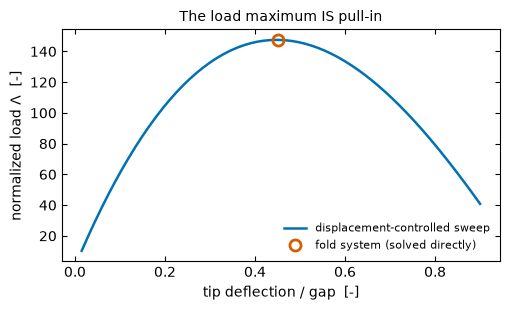

Lambda at pull-in   = 147.4997
sweep maximum       = 147.4997
[0.6s]


In [3]:
t0 = time.perf_counter()

Lam_PI, travel, s_grid, lam_curve = B.pullin_lambda(
    D_uni, alpha=ALPHA, N_t=0.0, N=N, bc=BC, n_delta=60)

fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.plot(np.asarray(s_grid), np.asarray(lam_curve), "-", lw=1.8,
        color="#0072B2", label="displacement-controlled sweep")
ax.plot([float(travel) / d_uni], [float(Lam_PI)], "o", ms=8, mfc="none",
        mew=2.0, color="#D55E00", label="fold system (solved directly)")
ax.set_xlabel("tip deflection / gap  [-]")
ax.set_ylabel(r"normalized load $\Lambda$  [-]")
ax.set_title("The load maximum IS pull-in", fontsize=10)
ax.tick_params(direction="in", top=True, right=True)
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

print(f"Lambda at pull-in   = {float(Lam_PI):.4f}")
print(f"sweep maximum       = {float(jnp.nanmax(lam_curve)):.4f}")
print(f"[{time.perf_counter() - t0:.1f}s]")

## 3. The gradient is exact — here is the proof

Because the fold point is a *root of a regular system*, the implicit function
theorem gives `∂Λ_PI/∂d(x)` exactly. One reverse-mode pass returns the
sensitivity to **every** node of the electrode profile at once.

To show that gradient is genuinely correct and not merely plausible, we use a
law it must obey. With fringing switched off, Λ_PI is a **degree-3 homogeneous**
function of the gap profile (scale the gap by `c`, the pull-in load scales by
`c³`). Euler's homogeneous function theorem then demands

$$\sum_i D_i \,\frac{\partial \Lambda}{\partial D_i} = 3\Lambda .$$

Nothing in the solver knows about this identity, so it is a real test.

In [4]:
t0 = time.perf_counter()

def lam_nofringe(D):
    lam, _, _, _ = B.pullin_fold(D, alpha=0.0, N_t=0.0, N=N, bc=BC, n_coarse=15)
    return lam

g0    = jax.grad(lam_nofringe)(D_uni)          # one pass, all 60 nodes
lam0  = float(lam_nofringe(D_uni))
euler = float(jnp.sum(D_uni * g0))

print("fringing OFF  (exact c^3 homogeneity expected)")
print(f"  sum(D . dLam/dD) = {euler:.6f}")
print(f"  3 * Lambda       = {3 * lam0:.6f}")
print(f"  relative error   = {abs(euler - 3*lam0) / (3*lam0) * 100:.6f}%")

# with the fringing correction on, homogeneity is broken BY THE PHYSICS,
# not by the numerics -- the residual is the fringing contribution itself.
def lam_of(D):
    lam, _, _, _ = evaluate(D, N, BC)
    return lam

g   = jax.grad(lam_of)(D_uni)
lam = float(lam_of(D_uni))
print("\nfringing ON   (homogeneity deliberately broken by the 1+alpha*G term)")
print(f"  relative error   = "
      f"{abs(float(jnp.sum(D_uni*g)) - 3*lam) / (3*lam) * 100:.4f}%")
print(f"[{time.perf_counter() - t0:.1f}s]")

fringing OFF  (exact c^3 homogeneity expected)
  sum(D . dLam/dD) = 448.145979
  3 * Lambda       = 448.145979
  relative error   = 0.000000%



fringing ON   (homogeneity deliberately broken by the 1+alpha*G term)
  relative error   = 0.4191%
[3.0s]


## 4. Inverse design: 22.86 V → 14.04 V, live

Now we use that gradient. We descend on a free-form gap profile
(12 cosine modes) against the pull-in voltage itself — not a surrogate, not a
proxy objective.

The travel specification is held by a **differentiable hard-constraint layer**
rather than a penalty: a Newton solve sets the gap scale so that
`travel == 2.0 µm` at every iterate, and the implicit function theorem carries
the gradient through it. Watch the `travel` column — it stays pinned at 2.0000
while the voltage falls. A soft penalty cannot do that; it trades spec
violation for voltage, because shrinking travel also shrinks V_PI.

~60 seconds.

In [5]:
t0 = time.perf_counter()

def D_of(p, sigma):
    return 1.0 + sigma * shape_norm(p, xi)

def travel_of(p, sigma):
    _, tr, _, _ = evaluate(D_of(p, sigma), N, BC)
    return tr

@jit
def sigma_newton(p, sigma):
    tr, dtr = jax.value_and_grad(lambda s: travel_of(p, s))(sigma)
    return sigma - (tr - TRAVEL_REQ) / dtr, dtr

def objective(p, sigma, dtr, z0):
    tr    = travel_of(p, sigma)                     # p-dependence stays live
    sig_c = sigma - (tr - TRAVEL_REQ) / jax.lax.stop_gradient(dtr)
    lam, tr2, res, z = evaluate(D_of(p, sig_c), N, BC, z0=z0)
    return volts(lam), (tr2, res, z, sig_c)

obj_and_grad = jit(jax.value_and_grad(objective, has_aux=True))

p, sigma = jnp.zeros(K).at[0].set(1.0), jnp.array(1.0)   # a UNIFORM gap start
zz = B.fold_initial_guess(D_of(p, sigma), ALPHA, 0.0, N, BC, n_coarse=15)
for _ in range(6):
    sigma, dtr = sigma_newton(p, sigma)

m = jnp.zeros_like(p); vv = jnp.zeros_like(p); hist = []
print("  iter    V_PI [V]    travel [um]    |residual|")
for it in range(1, 151):
    sigma, dtr = sigma_newton(jax.lax.stop_gradient(p), sigma)
    (v, (tr, res, z_new, sig_c)), g = obj_and_grad(p, sigma, dtr, zz)
    zz, sigma = jnp.where(res < 1e-6, z_new, zz), sig_c
    m  = 0.9   * m  + 0.1   * g
    vv = 0.999 * vv + 0.001 * g ** 2
    p  = p - 0.02 * (m / (1 - 0.9 ** it)) / (jnp.sqrt(vv / (1 - 0.999 ** it)) + 1e-9)
    hist.append(float(v))
    if it % 30 == 0 or it == 1:
        print(f"  {it:4d}    {float(v):8.3f}    {float(tr):10.4f}    "
              f"{float(res):.1e}")

print(f"\n  {V_uni:.3f} V  ->  {hist[-1]:.3f} V"
      f"   ({100*(V_uni-hist[-1])/V_uni:.1f}% reduction)"
      f"  in {time.perf_counter()-t0:.0f}s")

  iter    V_PI [V]    travel [um]    |residual|


     1      22.864        2.0000    4.6e-08


    30      17.639        2.0000    6.1e-08


    60      15.652        2.0000    4.5e-08


    90      14.715        2.0000    4.7e-08


   120      14.279        2.0000    5.9e-08


   150      14.037        2.0000    5.4e-08

  22.864 V  ->  14.037 V   (38.6% reduction)  in 59s


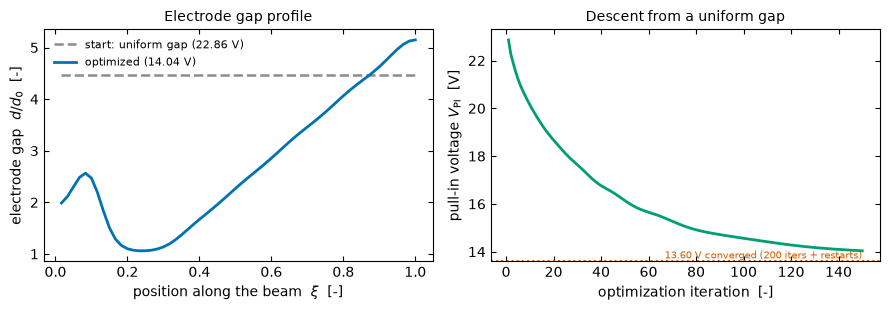

In [6]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9.0, 3.2))

a.plot(np.asarray(xi), np.asarray(D_uni), "--", lw=1.8, color="#8C8C8C",
       label=f"start: uniform gap ({V_uni:.2f} V)")
a.plot(np.asarray(xi), np.asarray(D_of(p, sigma)), "-", lw=2.0,
       color="#0072B2", label=f"optimized ({hist[-1]:.2f} V)")
a.set_xlabel(r"position along the beam  $\xi$  [-]")
a.set_ylabel(r"electrode gap  $d/d_0$  [-]")
a.set_title("Electrode gap profile", fontsize=10)
a.tick_params(direction="in", top=True, right=True)
a.legend(fontsize=8, frameon=False)

b.plot(np.arange(1, len(hist) + 1), hist, "-", lw=2.0, color="#009E73")
b.axhline(13.60, ls=":", lw=1.4, color="#D55E00")
b.text(len(hist), 13.72, "13.60 V converged (200 iters + restarts)",
       fontsize=7.5, ha="right", color="#D55E00")
b.set_xlabel("optimization iteration  [-]")
b.set_ylabel(r"pull-in voltage $V_{\rm PI}$  [V]")
b.set_title("Descent from a uniform gap", fontsize=10)
b.tick_params(direction="in", top=True, right=True)

plt.tight_layout(); plt.show()

## What just happened

You started from a uniform-gap cantilever needing **22.86 V**, and 150 gradient
steps later had a profile needing **~14.04 V** — a **~39% drive-voltage
reduction from electrode geometry alone**: no new material, no extra process
step, no extra mask. Running the full schedule (200 iterations plus restarts)
reaches **13.60 V, −41%**.

Every gradient came from the physics. Zero simulations were stored, zero
training data was used, and no commercial licence was involved.

**Not shown here, because they take longer than 90 seconds:**

| | Script | Cost |
|---|---|---|
| Validation against 8 sources, 1967–2025 | `test_fold.py`, `validate_*.py`, `model2dof.py` | ~2 min each |
| Amortized network — spec → geometry in 0.04 ms | `amortized_hard.py` | 26 min to train |
| RL policy — +12.8% travel, 0% devices destroyed | `train_rl2dof.py` | GPU, ~10 min |
| Surrogate baselines at equal budget (MLP, FNO) | `surrogate_fair.py`, `fno_surrogate.py` | ~10 min |
| All figures and tables | `gen_figdata.py`, `make_figures.py` | ~30 min |

The full quantitative comparison, including the results that went against us,
is in `submission/03_results_and_validation.md`.
